In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
import tensorflow.keras.backend as K

2026-04-08 12:35:16.634055: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775651716.904077      33 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775651716.984401      33 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
train_data = pd.read_csv("/kaggle/input/playground-series-s5e5/train.csv", index_col = "id")
test_data = pd.read_csv("/kaggle/input/playground-series-s5e5/test.csv", index_col = "id")

In [3]:
train_data.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
id,,,,,,,,
0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


In [4]:
test_data.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
id,,,,,,,
750000,male,45,177.0,81.0,7.0,87.0,39.8
750001,male,26,200.0,97.0,20.0,101.0,40.5
750002,female,29,188.0,85.0,16.0,102.0,40.4
750003,female,39,172.0,73.0,20.0,107.0,40.6
750004,female,30,173.0,67.0,16.0,94.0,40.5


In [5]:
print("Training Data Shape :", train_data.shape)
print("Testing Data Shape :", test_data.shape)

Training Data Shape : (750000, 8)
Testing Data Shape : (250000, 7)


# Basic EDA

In [6]:
print("#" * 50)
print(train_data.info())
print("#" * 50)
print(test_data.info())
print("#" * 50)
print("#" * 50)
display(train_data.describe())
print("#" * 50)
display(test_data.describe())

##################################################
<class 'pandas.core.frame.DataFrame'>
Index: 750000 entries, 0 to 749999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Sex         750000 non-null  object 
 1   Age         750000 non-null  int64  
 2   Height      750000 non-null  float64
 3   Weight      750000 non-null  float64
 4   Duration    750000 non-null  float64
 5   Heart_Rate  750000 non-null  float64
 6   Body_Temp   750000 non-null  float64
 7   Calories    750000 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 51.5+ MB
None
##################################################
<class 'pandas.core.frame.DataFrame'>
Index: 250000 entries, 750000 to 999999
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Sex         250000 non-null  object 
 1   Age         250000 non-null  int64  
 2   Height      250000 non

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


##################################################


,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,41.452464,174.725624,75.147712,15.415428,95.479084,40.036093
std,15.177769,12.822039,13.979513,8.349133,9.450161,0.778448
min,20.000000,127.000000,39.000000,1.000000,67.000000,37.100000
25%,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000
50%,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000
75%,52.000000,185.000000,87.000000,23.000000,103.000000,40.600000
max,79.000000,219.000000,126.000000,30.000000,128.000000,41.500000


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


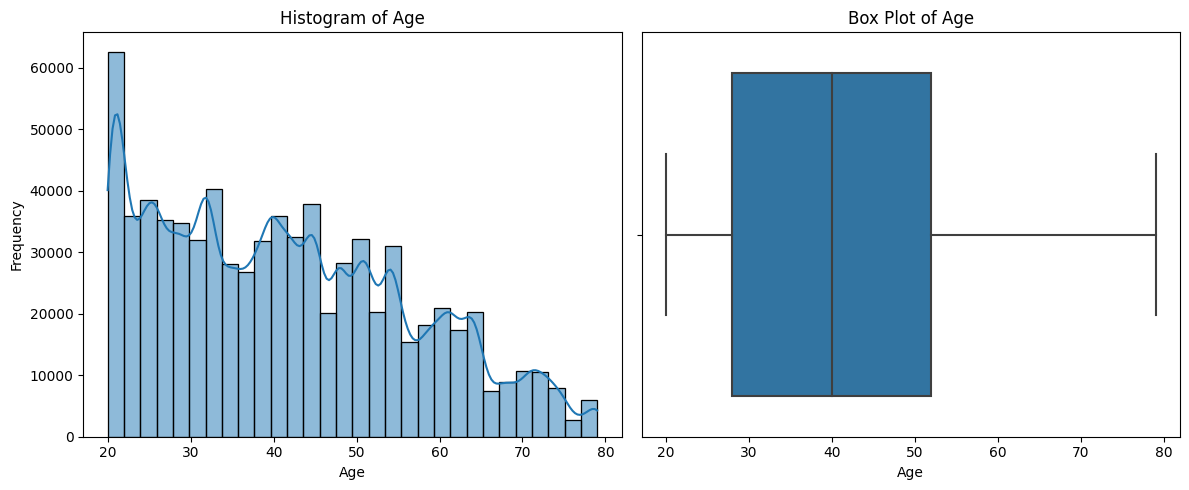


Statistics for Age:
Skewness: 0.44
Number of Missing Values: 0


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


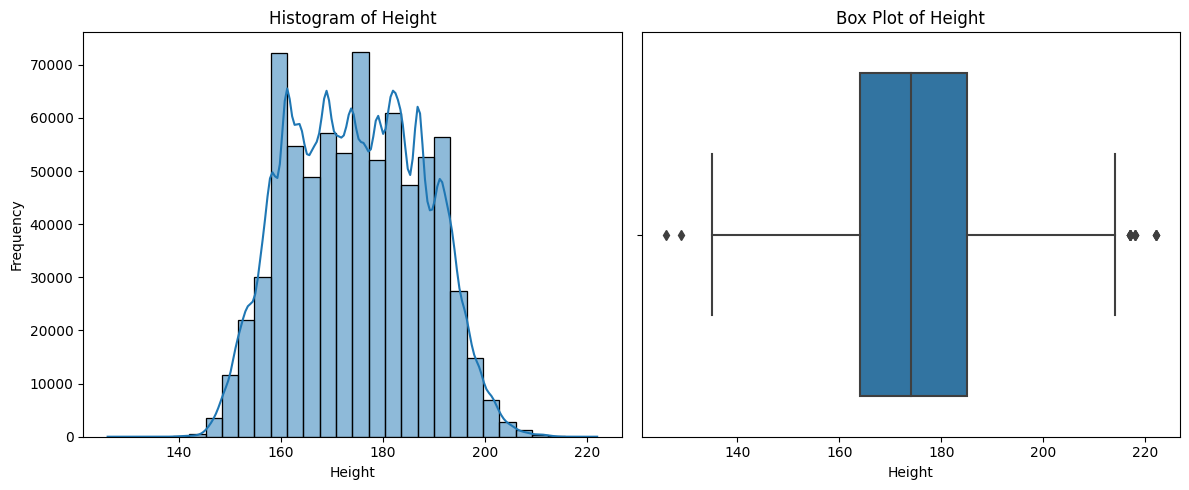


Statistics for Height:
Skewness: 0.05
Number of Missing Values: 0


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


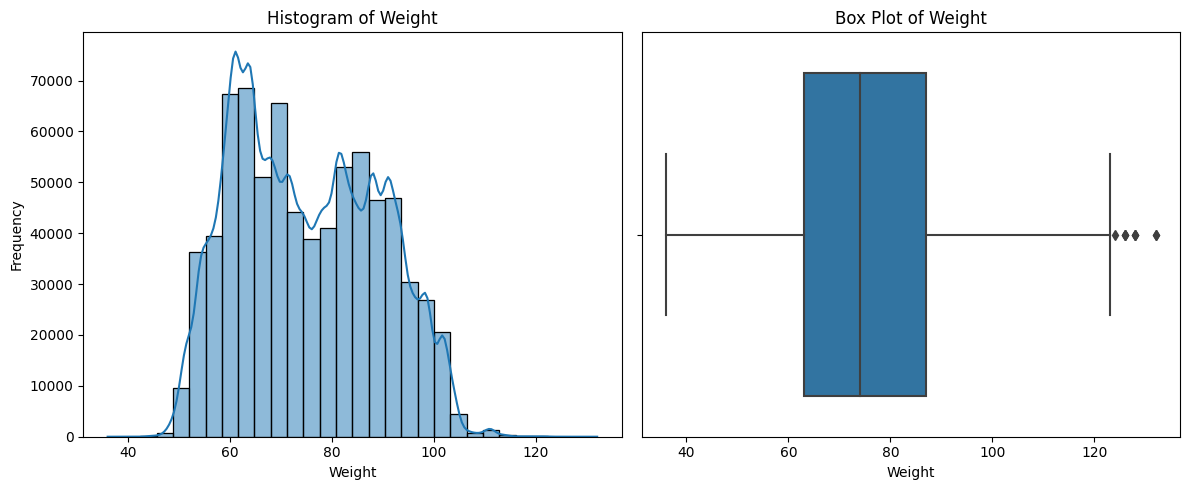


Statistics for Weight:
Skewness: 0.21
Number of Missing Values: 0


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


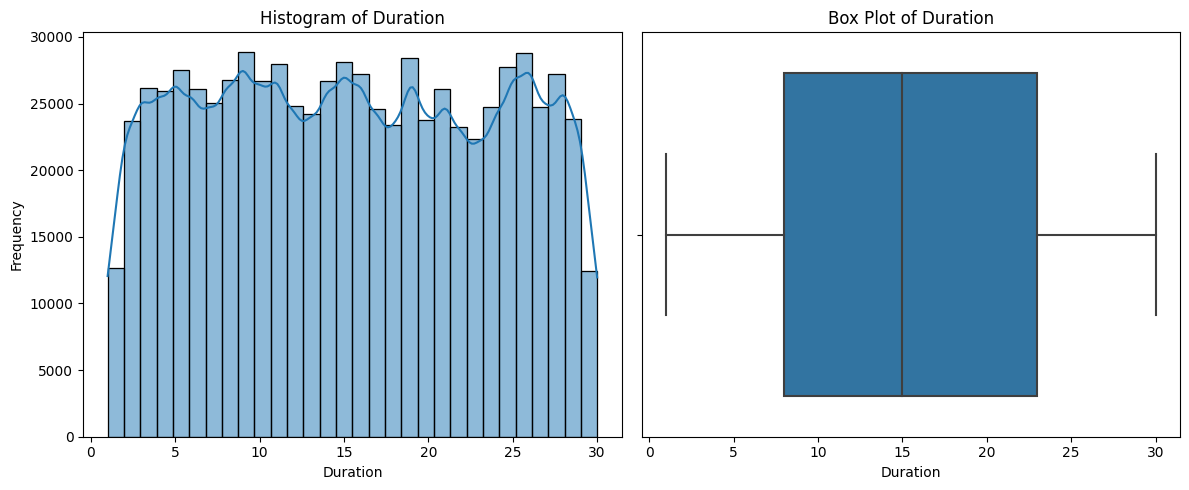


Statistics for Duration:
Skewness: 0.03
Number of Missing Values: 0


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


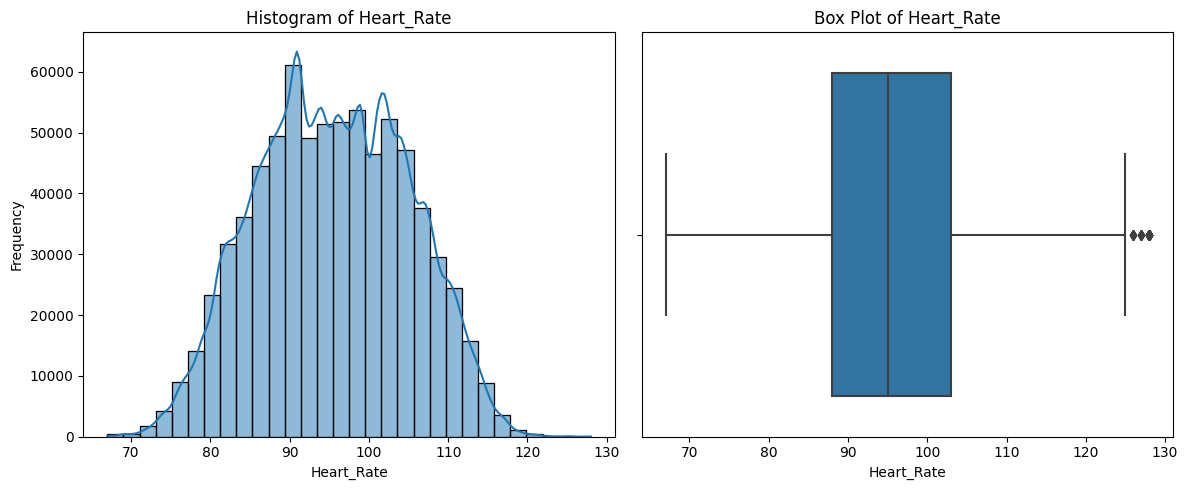


Statistics for Heart_Rate:
Skewness: -0.01
Number of Missing Values: 0


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


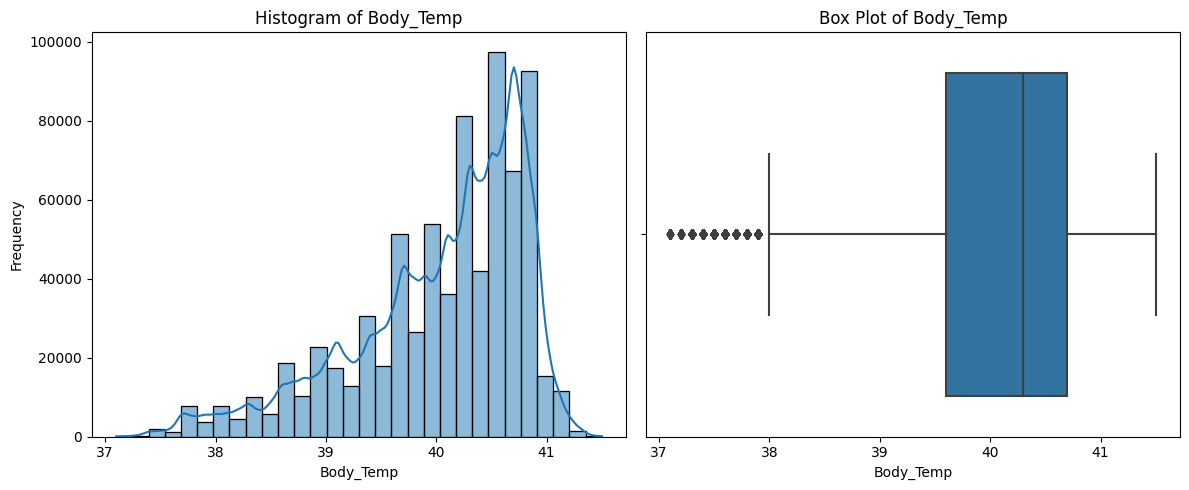


Statistics for Body_Temp:
Skewness: -1.02
Number of Missing Values: 0


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


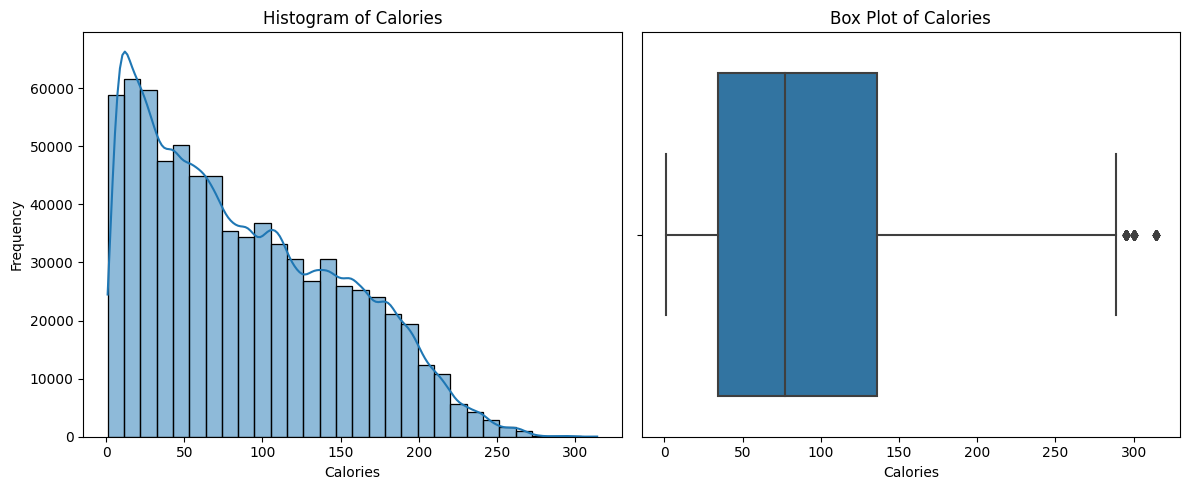


Statistics for Calories:
Skewness: 0.54
Number of Missing Values: 0


In [7]:
numerical_features = [
    "Age",
    "Height",
    "Weight",
    "Duration",
    "Heart_Rate",
    "Body_Temp",
    "Calories"
    
]

for feature in numerical_features:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.histplot(train_data[feature], kde=True, bins=30)
    plt.title(f"Histogram of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=train_data[feature])
    plt.title(f"Box Plot of {feature}")

    plt.tight_layout()
    plt.show()

    print(f"\nStatistics for {feature}:")
    print(f"Skewness: {train_data[feature].skew():.2f}")
    print(f"Number of Missing Values: {train_data[feature].isnull().sum()}")


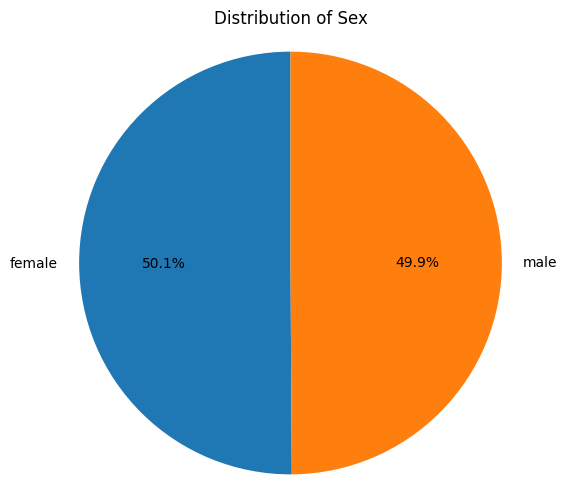

Missing Values in Calories: 0


In [8]:
sex_counts = train_data["Sex"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Distribution of Sex")
plt.axis("equal")
plt.show()

print(f"Missing Values in {feature}: {train_data[feature].isnull().sum()}")

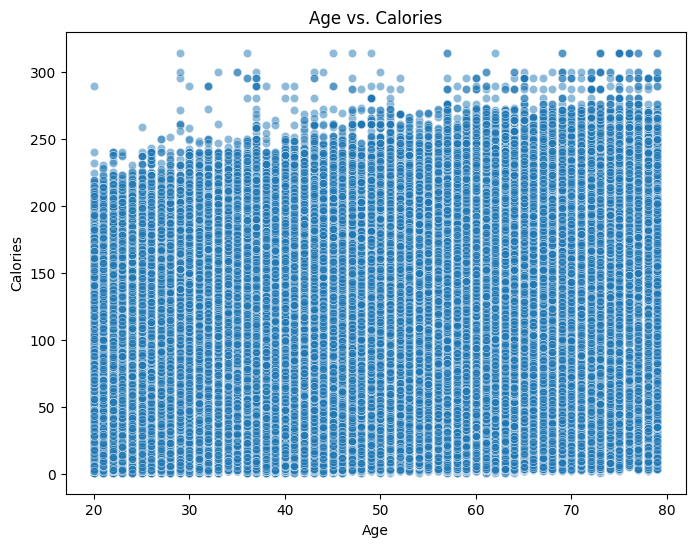

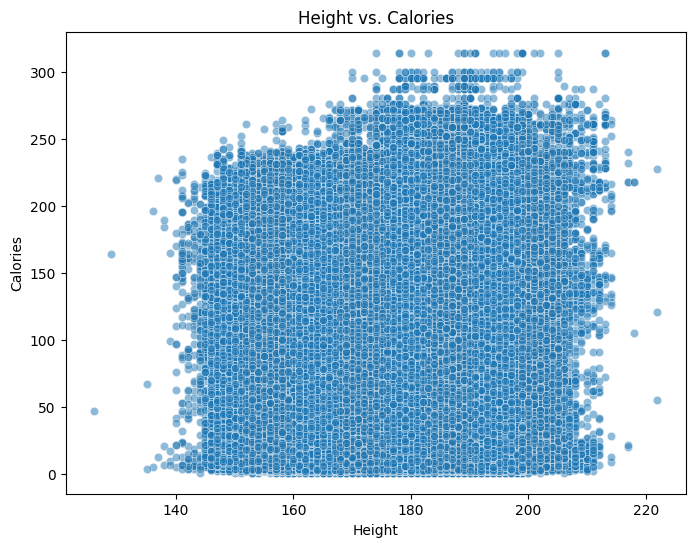

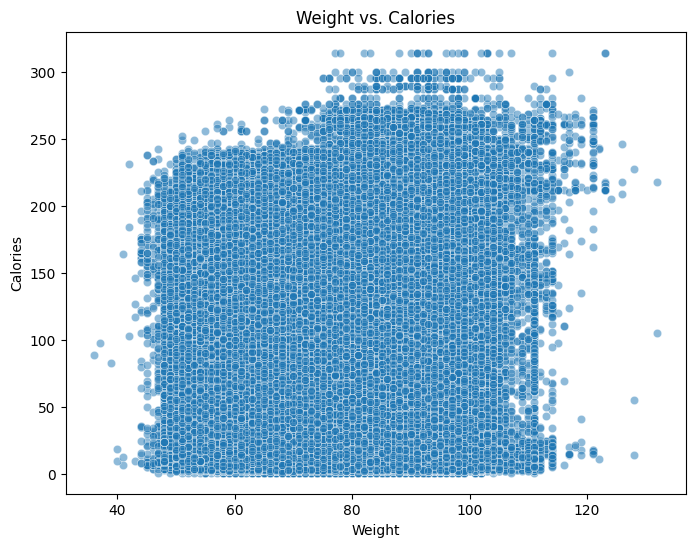

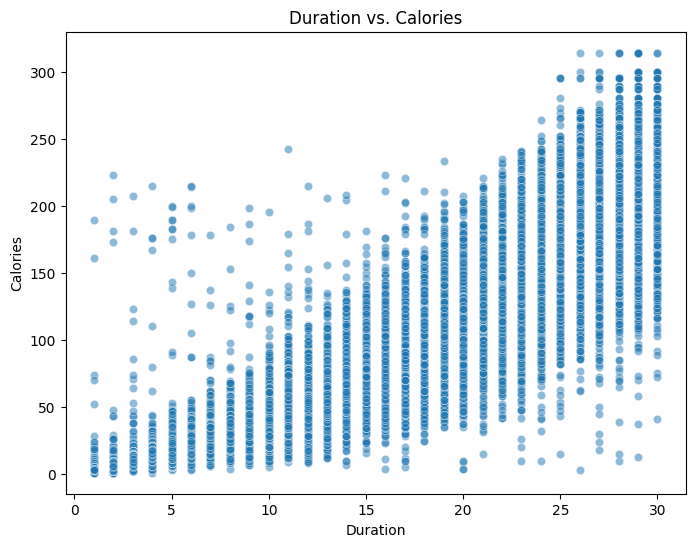

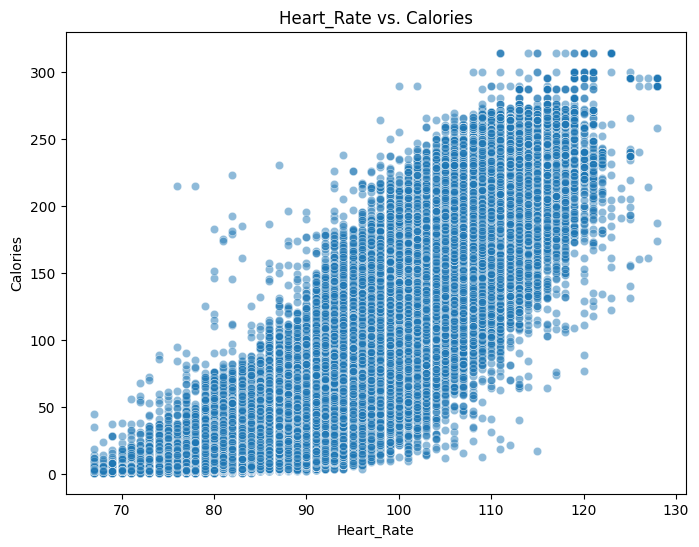

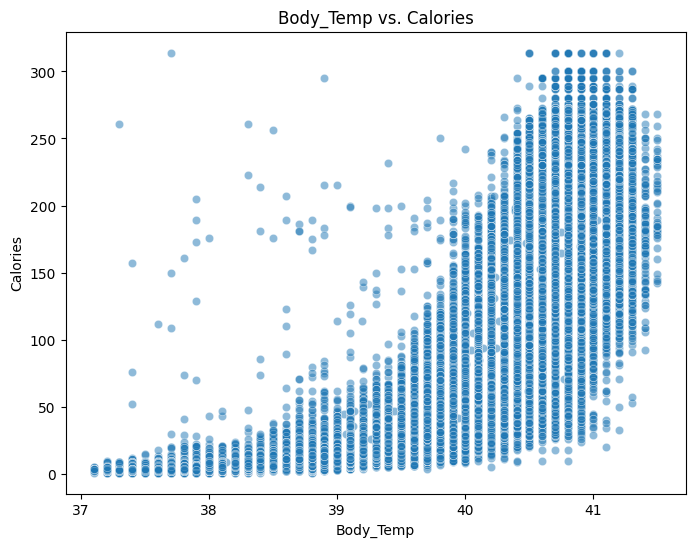

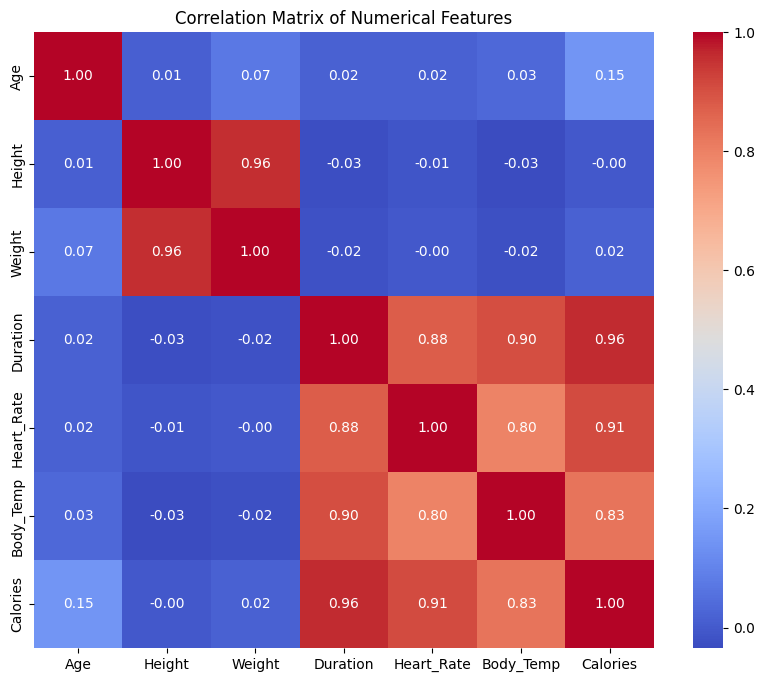

In [9]:
for feature in numerical_features[:-1]:  
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=train_data[feature], y=train_data["Calories"], alpha=0.5
    )
    plt.title(f"{feature} vs. Calories")
    plt.xlabel(feature)
    plt.ylabel("Calories")
    plt.show()

correlation_matrix = train_data[numerical_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

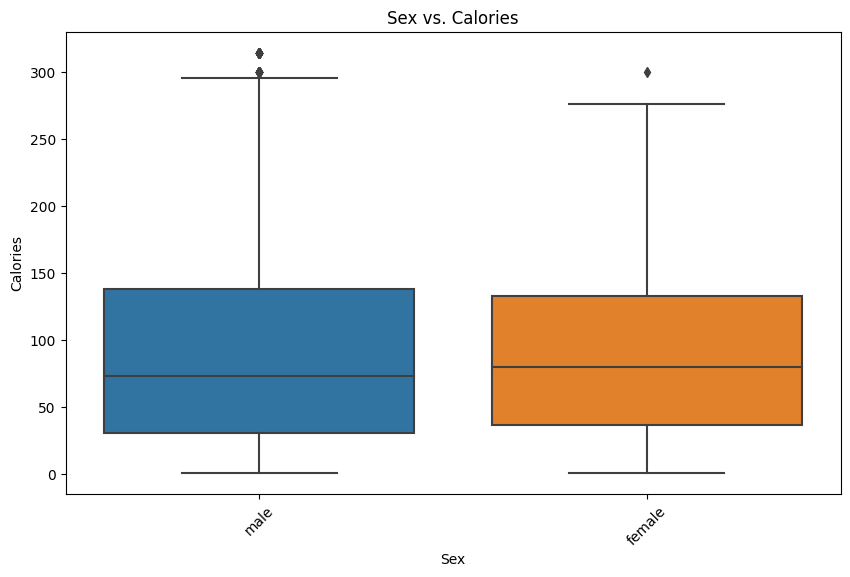

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=train_data["Sex"], y=train_data["Calories"])
plt.title("Sex vs. Calories")
plt.xlabel("Sex")
plt.ylabel("Calories")
plt.xticks(rotation=45)
plt.show()

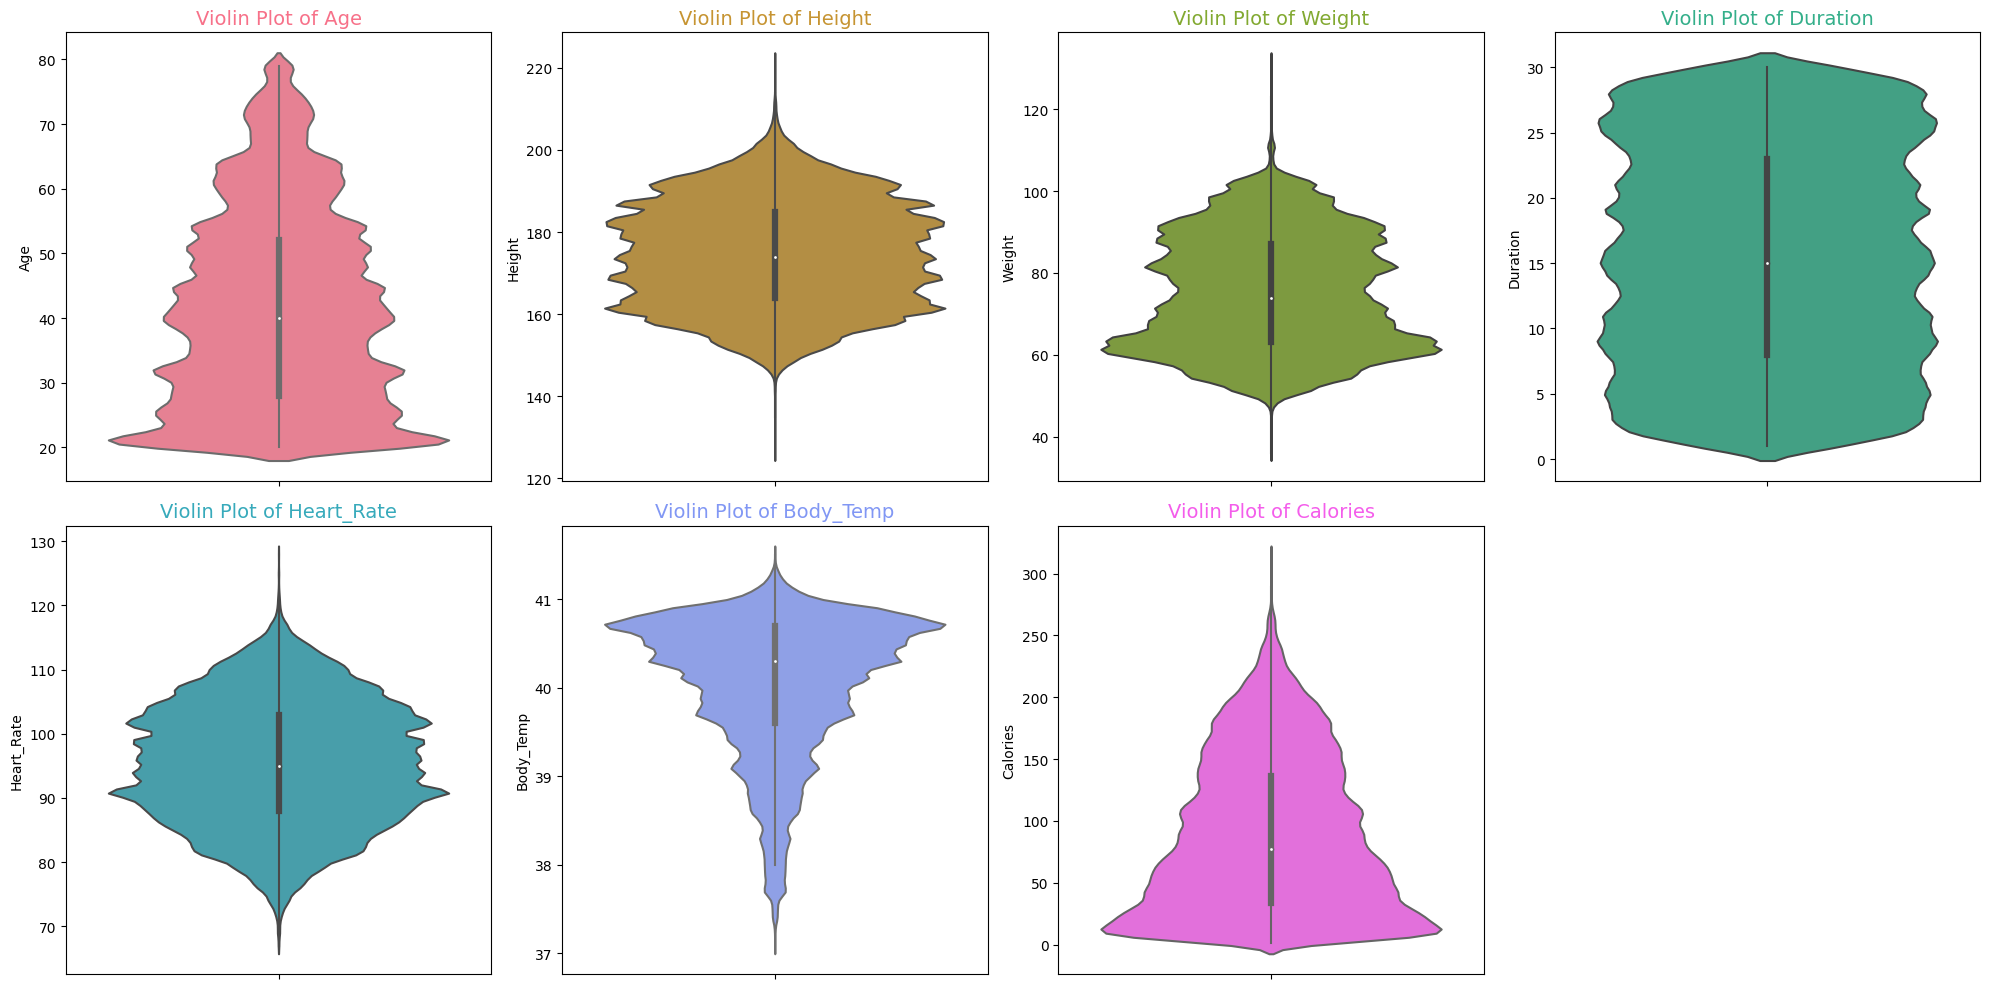

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

colors = sns.color_palette('husl', len(numerical_features))
rows = -(-len(numerical_features) // 4)
plt.figure(figsize=(20, 5 * rows))

for i, (col, color) in enumerate(zip(numerical_features, colors), 1):
    plt.subplot(rows, 4, i)
    sns.violinplot(data=train_data, y=col, color=color)
    plt.title(f'Violin Plot of {col}', fontsize=14, color=color)
    plt.xlabel('')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

# Feature Engineering

In [12]:
train_data = pd.get_dummies(train_data, columns=['Sex'], prefix=['Sex'])
test_data = pd.get_dummies(test_data, columns=['Sex'], prefix=['Sex'])

In [13]:
train_data["BMI"] = train_data["Weight"] / (train_data["Height"]**2)
test_data["BMI"] = test_data["Weight"] / (test_data["Height"]**2)

train_data["DurxHR"] = train_data["Duration"] * train_data["Heart_Rate"]
test_data["DurxHR"] = test_data["Duration"] * test_data["Heart_Rate"]

train_data["AgexWt"] = train_data["Age"] * train_data["Weight"]
test_data["AgexWt"] = test_data["Age"] * test_data["Weight"]

train_data['Weight_per_Age'] = train_data['Weight'] / train_data['Age']
test_data['Weight_per_Age'] = test_data['Weight'] / test_data['Age']

train_data['Height_per_Age'] = train_data['Height'] / train_data['Age']
test_data['Height_per_Age'] = test_data['Height'] / test_data['Age']

train_data['Age_Height'] = train_data['Age'] * train_data['Height']
test_data['Age_Height'] = test_data['Age'] * test_data['Height']

train_data['log_Age'] = np.log1p(train_data['Age'])
test_data['log_Age'] = np.log1p(test_data['Age'])
train_data['Weight_squared'] = train_data['Weight'] ** 2
test_data['Weight_squared'] = test_data['Weight'] ** 2

train_data['Age_Adjusted_Body_Index'] = (train_data['Height'] / train_data['Weight']) * train_data['Age']
test_data['Age_Adjusted_Body_Index'] = (test_data['Height'] / test_data['Weight']) * test_data['Age']

In [14]:
def get_heart_rate_zone(heart_rate, age):
    
    # Compute heart rate zone based on % of maximum heart rate.
    
    max_hr = 220 - age
    hr_percent = heart_rate / max_hr

    if hr_percent < 0.6:
        return 'Zone 1: Warm-up'
    elif hr_percent < 0.7:
        return 'Zone 2: Fat Burn'
    elif hr_percent < 0.8:
        return 'Zone 3: Cardio'
    elif hr_percent < 0.9:
        return 'Zone 4: Hard'
    else:
        return 'Zone 5: Maximum Effort'

train_data['Heart_Rate_Zone'] = train_data.apply(
    lambda row: get_heart_rate_zone(row['Heart_Rate'], row['Age']),
    axis=1
)
test_data['Heart_Rate_Zone'] = test_data.apply(
    lambda row: get_heart_rate_zone(row['Heart_Rate'], row['Age']),
    axis=1
)
zone_map = {
    'Zone 1: Warm-up': 1,
    'Zone 2: Fat Burn': 2,
    'Zone 3: Cardio': 3,
    'Zone 4: Hard': 4,
    'Zone 5: Maximum Effort': 5
}

train_data['Heart_Rate_Zone_Code'] = train_data['Heart_Rate_Zone'].map(zone_map)
train_data = train_data.drop('Heart_Rate_Zone', axis = 1)
test_data['Heart_Rate_Zone_Code'] = test_data['Heart_Rate_Zone'].map(zone_map)
test_data = test_data.drop('Heart_Rate_Zone', axis = 1)

In [15]:
def get_age_bins(age):
    
    if age > 70:
        return 'Age 70+'
    elif age > 60:
        return 'Age 60-70'
    elif age > 50:
        return 'Age 50-60'
    elif age > 40:
        return 'Age 40-50'
    elif age > 30:
        return 'Age 30-40'
    else:
        return 'Age 20-30'

train_data['Age_Bins'] = train_data.apply(
    lambda row: get_age_bins(row['Age']),
    axis=1
)
test_data['Age_Bins'] = test_data.apply(
    lambda row: get_age_bins(row['Age']),
    axis=1
)
age_map = {
    'Age 20-30': 1,
    'Age 30-40': 2,
    'Age 40-50': 3,
    'Age 50-60': 4,
    'Age 60-70': 5,
    'Age 70+': 6
}

train_data['Age_Bins'] = train_data['Age_Bins'].map(age_map)
test_data['Age_Bins'] = test_data['Age_Bins'].map(age_map)

In [16]:
train_data

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,Sex_female,Sex_male,BMI,DurxHR,AgexWt,Weight_per_Age,Height_per_Age,Age_Height,log_Age,Weight_squared,Age_Adjusted_Body_Index,Heart_Rate_Zone_Code,Age_Bins
id,,,,,,,,,,,,,,,,,,,,
0,36,189.0,82.0,26.0,101.0,41.0,150.0,False,True,0.002296,2626.0,2952.0,2.277778,5.250000,6804.0,3.610918,6724.0,82.975610,1,2
1,64,163.0,60.0,8.0,85.0,39.7,34.0,True,False,0.002258,680.0,3840.0,0.937500,2.546875,10432.0,4.174387,3600.0,173.866667,1,5
2,51,161.0,64.0,7.0,84.0,39.8,29.0,True,False,0.002469,588.0,3264.0,1.254902,3.156863,8211.0,3.951244,4096.0,128.296875,1,4
3,20,192.0,90.0,25.0,105.0,40.7,140.0,False,True,0.002441,2625.0,1800.0,4.500000,9.600000,3840.0,3.044522,8100.0,42.666667,1,1
4,38,166.0,61.0,25.0,102.0,40.6,146.0,True,False,0.002214,2550.0,2318.0,1.605263,4.368421,6308.0,3.663562,3721.0,103.409836,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,28,193.0,97.0,30.0,114.0,40.9,230.0,False,True,0.002604,3420.0,2716.0,3.464286,6.892857,5404.0,3.367296,9409.0,55.711340,1,1
749996,64,165.0,63.0,18.0,92.0,40.5,96.0,True,False,0.002314,1656.0,4032.0,0.984375,2.578125,10560.0,4.174387,3969.0,167.619048,1,5
749997,60,162.0,67.0,29.0,113.0,40.9,221.0,False,True,0.002553,3277.0,4020.0,1.116667,2.700000,9720.0,4.110874,4489.0,145.074627,3,4


In [17]:
X = train_data.drop(columns=['Calories', 'Sex_male'])
y = train_data['Calories']

scaler = StandardScaler()

X = scaler.fit_transform(X)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Selection and Scoring

In [18]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [19]:
en = ElasticNet()
en.fit(X_train, y_train)

ElasticNet()

In [20]:
xgb_model = XGBRegressor(n_estimators= 500, max_depth = 10, learning_rate = 0.05, subsample = 1.0, colsample_bytree = 0.8, random_state=42)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [21]:
lgb_model = LGBMRegressor(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    subsample=1.0,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.057999 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2300
[LightGBM] [Info] Number of data points in the train set: 600000, number of used features: 18
[LightGBM] [Info] Start training from score 88.298465


LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, max_depth=10,
              n_estimators=500, n_jobs=-1, random_state=42)

In [22]:
# train_data.drop(["BMI", "Height", "Weight_squared", "Weight", "Weight_per_Age", "Height_per_Age", "Sex_female"], axis = 1)
# test_data.drop(["BMI", "Height", "Weight_squared", "Weight", "Weight_per_Age", "Height_per_Age", "Sex_female"], axis = 1)

In [25]:
model = Sequential([
    Input(shape=(18,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='relu')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss=tf.keras.losses.MeanAbsoluteError(),
    metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                      │ (None, 128)                 │           2,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 32)                  │           1,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,529 (72.38 KB)

 Trainable params: 18,529 (72.38 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=40,
    batch_size=256,
    verbose=1
)

Epoch 1/40
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 6.0441 - mae: 6.0441 - val_loss: 2.4445 - val_mae: 2.4445
Epoch 2/40
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 2.6532 - mae: 2.6532 - val_loss: 2.2220 - val_mae: 2.2220
Epoch 3/40
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 2.5123 - mae: 2.5123 - val_loss: 2.7687 - val_mae: 2.7687
Epoch 4/40
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 2.4410 - mae: 2.4410 - val_loss: 2.4332 - val_mae: 2.4332
Epoch 5/40
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 2.4172 - mae: 2.4172 - val_loss: 2.2068 - val_mae: 2.2068
Epoch 6/40
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 2.3591 - mae: 2.3591 - val_loss: 2.7787 - val_mae: 2.7787
Epoch 7/40
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 2.3750 - mae: 2.3750 - val_loss: 2.3437 - val_mae: 2.3437
Epoch 8/40
2344/2344 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 2.3350 - mae: 2.3350 - val_loss: 2.3496 - val_mae: 2.3496
Epoch 9/40
2344/2344 ━━━━━━━━━━━━━━━━━━━

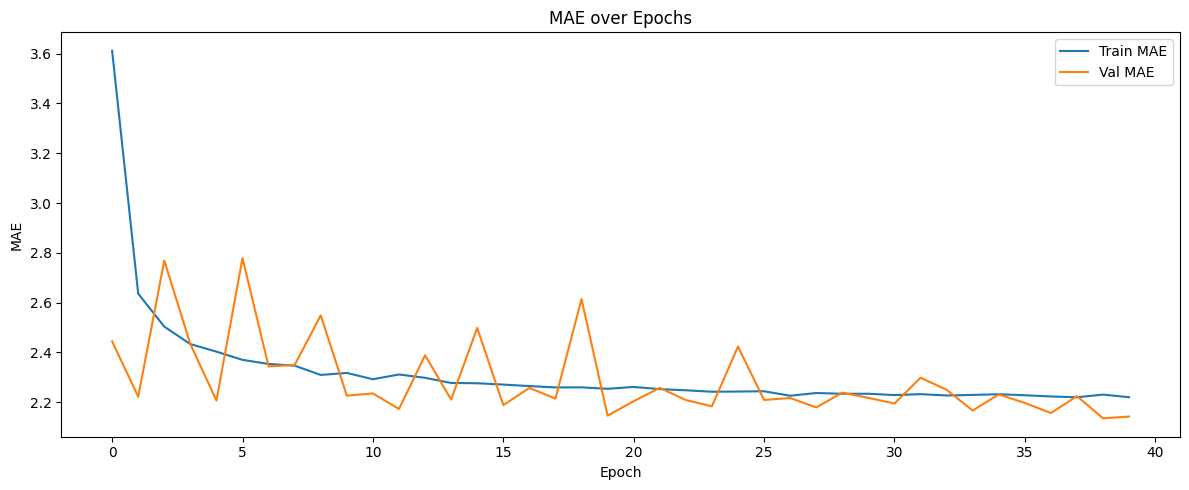

In [27]:
plt.figure(figsize=(12, 5))

# MAE
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('MAE over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
y_data_lr = lr.predict(X_valid)
y_data_en = en.predict(X_valid)
y_data_xgb = xgb_model.predict(X_valid)
y_data_lgb = lgb_model.predict(X_valid)
y_data_nn = model.predict(X_valid).flatten()

4688/4688 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


In [29]:
from sklearn.metrics import mean_squared_error

print("Linear Regression :", mean_squared_error(y_data_lr, y_valid))
print("ElasticNet :", mean_squared_error(y_data_en, y_valid))
print("XGBoost :", mean_squared_error(y_data_xgb, y_valid))
print("Light GBM :", mean_squared_error(y_data_lgb, y_valid))
print("Neural Network :", mean_squared_error(y_data_nn, y_valid))

Linear Regression : 43.39000769649502
ElasticNet : 204.92677596381725
XGBoost : 12.94836649355553
Light GBM : 13.216583379386819
Neural Network : 13.373571232580952


In [31]:
test_data = test_data.drop(columns = ["Sex_male"])
test_data = scaler.transform(test_data)

In [32]:
y_data = xgb_model.predict(test_data)

In [33]:
custom_index = np.arange(750000, 1000000)

df_predictions = pd.DataFrame({'Calories': y_data}, index=custom_index)

df_predictions.reset_index(drop=False, inplace=True)

df_predictions.rename(columns={'index': 'id'}, inplace=True)

In [34]:
df_predictions.to_csv("Final_Predictions.csv", index = False)

In [35]:
df_predictions.head()

,id,Calories
0,750000,27.437429
1,750001,107.188065
2,750002,86.964294
3,750003,125.590485
4,750004,76.415321


In [36]:
id_no = int(input("Enter ID Number :"))
sex = input("Enter Gender :")
age = int(input("Enter Age :"))
height = int(input("Enter Height (in cm) :"))
weight = int(input("Enter Weight (in kg) :"))
duration = int(input("Enter duration of exercises (in min.) : "))
heart_rate = int(input("Enter Heart Rate :"))
body_temp = int(input("Enter Body Temperature : "))

Enter ID Number : 1000
Enter Gender : male
Enter Age : 20
Enter Height (in cm) : 180
Enter Weight (in kg) : 80
Enter duration of exercises (in min.) :  35
Enter Heart Rate : 120
Enter Body Temperature :  41


In [37]:
sex_female = sex == "female"
bmi = weight / (height**2)
DurxHR = duration * heart_rate
AgexWt = age * weight
Weight_per_Age = weight / age
Height_per_Age = height / age
Age_Height = age * height
log_Age = np.log1p(age)
weight_squared = weight ** 2
Age_Adjusted_Body_Index = (height / weight) * age

In [38]:
heart_rate_zone = get_heart_rate_zone(heart_rate, age)

if '1' in heart_rate_zone:
    Heart_Rate_Zone_Code = 1
elif '2' in heart_rate_zone:
    Heart_Rate_Zone_Code = 2
if '3' in heart_rate_zone:
    Heart_Rate_Zone_Code = 3
elif '4' in heart_rate_zone:
    Heart_Rate_Zone_Code = 4
else:
    Heart_Rate_Zone_Code = 5

In [39]:
if age > 70:
    age_bin = 6
elif age > 60:
    age_bin = 5
elif age > 50:
    age_bin = 4
elif age > 40:
    age_bin = 3
elif age > 30:
    age_bin = 2
else:
    age_bin = 1

In [40]:
arr = np.array([
    age, height, weight, duration, heart_rate, body_temp,
    sex_female, bmi, DurxHR, AgexWt, Weight_per_Age,
    Height_per_Age, Age_Height, log_Age, weight_squared,
    Age_Adjusted_Body_Index, Heart_Rate_Zone_Code, age_bin
])

test = scaler.transform(arr.reshape(1, -1))

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [47]:
output = xgb.predict(test)

In [48]:
output

array([305.72460879])